# Laporan Machine Learning — Smart Flood Warning System

**Deliverable spesifikasi §12 butir #7** — Dataset, EDA, preprocessing, training, cross-validation, evaluasi ketiga model.

**Kelompok:** kelompok2 · **Layanan:** `python-ml-service`

> Ekspor notebook ini ke PDF untuk pengumpulan: `jupyter nbconvert --to pdf notebooks/ML_Report.ipynb`


## Pemetaan model (Tugas Besar Smart City → Proyek Banjir)

| Model spesifikasi | Implementasi kami | Dataset | Algoritma | File model |
|-------------------|-------------------|---------|-----------|------------|
| Traffic Predictor | Prediksi curah hujan | `data/data_finish.csv` | Random Forest Regressor | `prediksi_curah_hujan.pkl` |
| Air Quality Classifier | Deteksi banjir (cuaca) | `data/data_finish.csv` | Random Forest Classifier | `deteksi_banjir_berdasarkan_cuaca.pkl` |
| Anomaly Detector | Deteksi anomali sensor | **Data sintetis** (Opsi A) | Isolation Forest | `deteksi_anomali.pkl` |

**Catatan Opsi A:** Label anomali sensor real-time jarang tersedia di dataset historis. Model anomali dilatih pada fitur sintetis (`sensor_value`, `timestamp_hour`, `rolling_mean_1h`, `z_score`) yang mengikuti pola distribusi pembacaan sensor banjir — selaras dengan `trains/train_model_anomaly.py` dan endpoint `POST /detect/anomaly`.


In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import IsolationForest, RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

ROOT = Path("..").resolve() if (Path.cwd().name == "notebooks") else Path(".").resolve()
DATA = ROOT / "data"
MODELS = ROOT / "models"
RANDOM_STATE = 42
CV_FOLDS = 5

print("ROOT:", ROOT)
print("Data files:", [p.name for p in DATA.glob("*.csv")])


ROOT: /Users/praffiramadhani/Documents/SEMESTER 4/pembangunan-perangkat-lunak-berorientasi-service/final-project/smart-flood-warning-and-monitoring-system/python-ml-service
Data files: ['Flood_Prediction_NCR_Philippines.csv', 'data_finish.csv']


## 1. Dataset

Dua dataset utama untuk EDA dan dua model pertama; model anomali memakai data sintetis (bagian 6).


In [2]:
df_ph = pd.read_csv(DATA / "Flood_Prediction_NCR_Philippines.csv")
df_id = pd.read_csv(DATA / "data_finish.csv")

print("=== Dataset Filipina (referensi EDA sensor air) ===")
print("Shape:", df_ph.shape)
display(df_ph.head())
print(df_ph.describe(include="all").T.head(10))

print("\n=== Dataset Indonesia (training cuaca & curah hujan) ===")
print("Shape:", df_id.shape)
display(df_id.head())
print("Kolom:", list(df_id.columns))
print("Distribusi label flood:")
print(df_id["flood"].value_counts(normalize=True).round(3))


=== Dataset Filipina (referensi EDA sensor air) ===
Shape: (7308, 7)


,Date,Location,Rainfall_mm,WaterLevel_m,SoilMoisture_pct,Elevation_m,FloodOccurrence
0,2016-01-01,Quezon City,12.0,0.5,15.3,43,0
1,2016-01-01,Marikina,10.6,1.8,23.2,15,0
2,2016-01-01,Manila,5.7,0.5,15.6,5,0
3,2016-01-01,Pasig,3.7,0.5,5.0,5,0
4,2016-01-02,Quezon City,3.4,0.5,13.3,43,0


                   count unique          top  freq       mean        std  min  \
Date                7308   1827   2016-01-01     4        NaN        NaN  NaN   
Location            7308      4  Quezon City  1827        NaN        NaN  NaN   
Rainfall_mm       7308.0    NaN          NaN   NaN  10.052874   7.101769  0.1   
WaterLevel_m      7308.0    NaN          NaN   NaN   1.266379   0.902239  0.5   
SoilMoisture_pct  7308.0    NaN          NaN   NaN  15.184989   5.994044  5.0   
Elevation_m       7308.0    NaN          NaN   NaN       17.0  15.557414  5.0   
FloodOccurrence   7308.0    NaN          NaN   NaN   0.018062   0.133186  0.0   

                   25%   50%   75%   max  
Date               NaN   NaN   NaN   NaN  
Location           NaN   NaN   NaN   NaN  
Rainfall_mm        4.9   8.4  13.5  52.7  
WaterLevel_m       0.5   1.0   1.8   6.4  
SoilMoisture_pct  10.9  14.9  19.1  39.7  
Elevation_m        5.0  10.0  22.0  43.0  
FloodOccurrence    0.0   0.0   0.0   1.0  

=== Da

,date,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car,station_id,station_name,region_name,flood
0,2016-01-01,26.0,34.8,28.6,81.0,NaN,5.8,5.0,280.0,2.0,S,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0
1,2016-01-02,25.6,33.2,27.0,88.0,1.6,8.7,4.0,290.0,2.0,W,96733,Stasiun Klimatologi Banten,Jakarta Selatan,1
2,2016-01-03,24.4,34.9,28.1,80.0,33.8,5.4,4.0,280.0,2.0,SW,96733,Stasiun Klimatologi Banten,Jakarta Selatan,1
3,2016-01-04,24.8,33.6,29.2,81.0,NaN,6.6,3.0,200.0,1.0,S,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0
4,2016-01-05,25.8,33.6,26.7,91.0,NaN,3.2,3.0,180.0,1.0,S,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0


Kolom: ['date', 'Tn', 'Tx', 'Tavg', 'RH_avg', 'RR', 'ss', 'ff_x', 'ddd_x', 'ff_avg', 'ddd_car', 'station_id', 'station_name', 'region_name', 'flood']
Distribusi label flood:
flood
0    0.925
1    0.075
Name: proportion, dtype: float64


## 2. Exploratory Data Analysis (EDA)


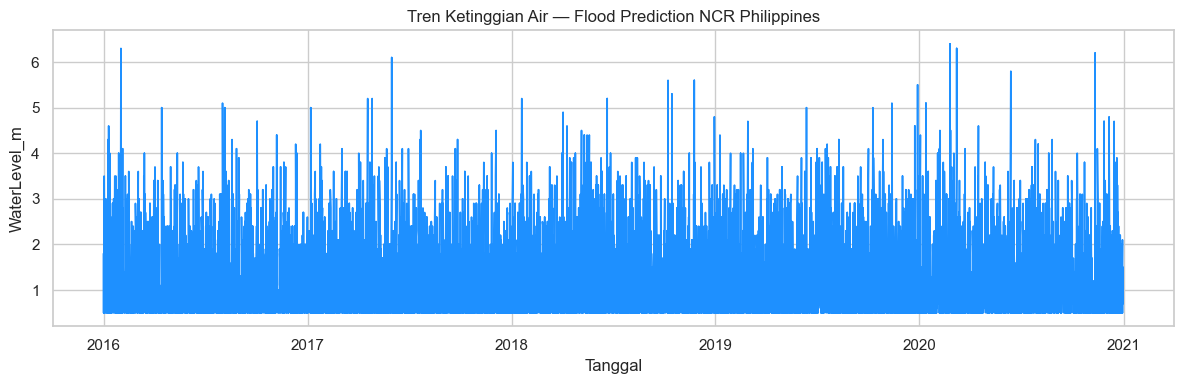

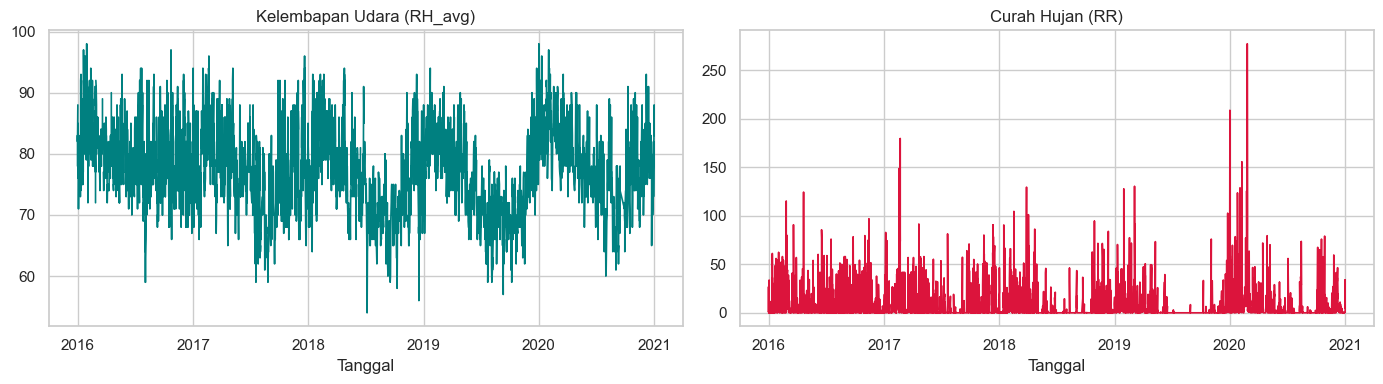

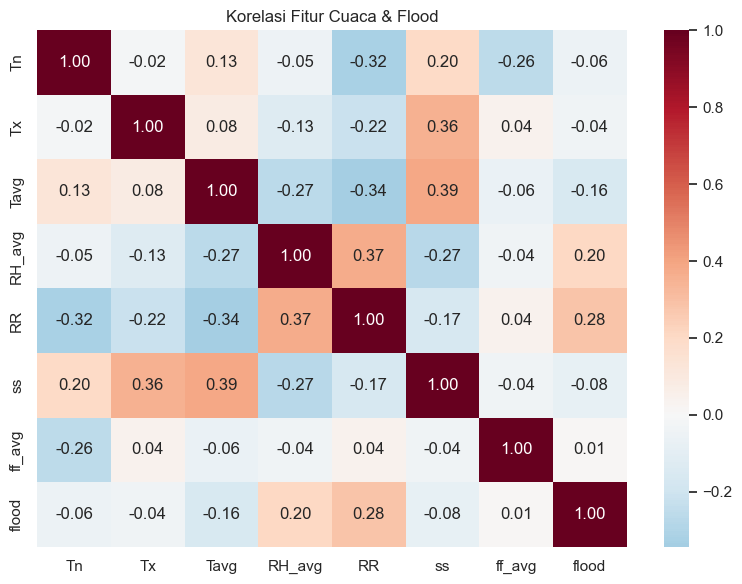

In [3]:
# EDA — tren ketinggian air (Filipina)
df_ph_sorted = df_ph.sort_values("Date")
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(pd.to_datetime(df_ph_sorted["Date"]), df_ph_sorted["WaterLevel_m"], color="dodgerblue", lw=1.2)
ax.set_title("Tren Ketinggian Air — Flood Prediction NCR Philippines")
ax.set_xlabel("Tanggal")
ax.set_ylabel("WaterLevel_m")
plt.tight_layout()
plt.show()

# EDA — curah hujan & kelembapan (Indonesia)
df_id_sorted = df_id.dropna(subset=["RR"]).sort_values("date")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(pd.to_datetime(df_id_sorted["date"]), df_id_sorted["RH_avg"], color="teal", lw=1.2)
axes[0].set_title("Kelembapan Udara (RH_avg)")
axes[1].plot(pd.to_datetime(df_id_sorted["date"]), df_id_sorted["RR"], color="crimson", lw=1.2)
axes[1].set_title("Curah Hujan (RR)")
for ax in axes:
    ax.set_xlabel("Tanggal")
plt.tight_layout()
plt.show()

# Korelasi fitur cuaca dengan flood
weather_cols = ["Tn", "Tx", "Tavg", "RH_avg", "RR", "ss", "ff_avg", "flood"]
corr = df_id[weather_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Korelasi Fitur Cuaca & Flood")
plt.tight_layout()
plt.show()


## 3. Preprocessing (umum)

Langkah yang dipakai di production (`trains/*.py`):

1. **Sampling** — `sample(frac=1.0, random_state=42)` untuk reproduksibilitas
2. **Missing values** — `dropna` pada kolom fitur regresi curah hujan
3. **Split** — `train_test_split(test_size=0.2, random_state=42)`
4. **Scaling** — `StandardScaler` khusus model anomali (Isolation Forest)
5. **Cross-validation** — `cross_val_score` 5-fold pada data training


## 4. Model 1 — Prediksi Curah Hujan (Traffic Predictor)

**Task:** Regresi · **Target:** `RR` (mm) · **Metrik:** R² (target spesifikasi ≥ 0.70)


Cross-validation R² (5-fold): 0.2406 ± 0.0449
Hold-out test R²: 0.2724
Status spesifikasi (≥70%): PERLU TUNING


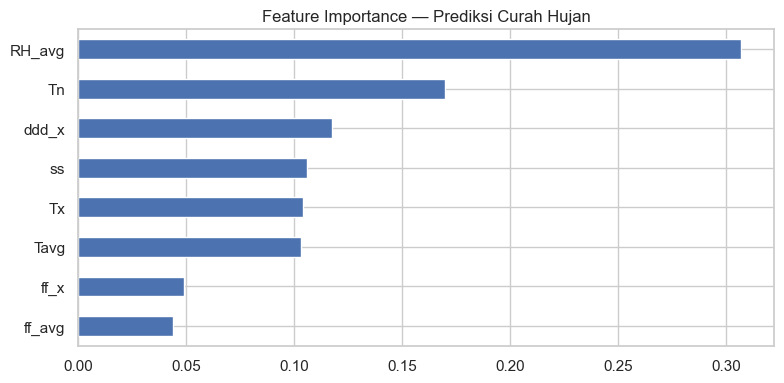

In [4]:
kolom_rr = ["Tn", "Tx", "Tavg", "RH_avg", "ss", "ff_x", "ddd_x", "ff_avg", "RR"]
df_rr = df_id.dropna(subset=kolom_rr).sample(frac=1.0, random_state=RANDOM_STATE)

FEATURES_RAIN = ["Tn", "Tx", "Tavg", "RH_avg", "ss", "ff_x", "ddd_x", "ff_avg"]
X_rain = df_rr[FEATURES_RAIN]
y_rain = df_rr["RR"]

X_train, X_test, y_train, y_test = train_test_split(
    X_rain, y_rain, test_size=0.2, random_state=RANDOM_STATE
)

model_rain = RandomForestRegressor(
    n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
)

cv_rain = cross_val_score(model_rain, X_train, y_train, cv=CV_FOLDS, scoring="r2", n_jobs=-1)
model_rain.fit(X_train, y_train)
y_pred_rain = model_rain.predict(X_test)
test_r2_rain = r2_score(y_test, y_pred_rain)

print(f"Cross-validation R² ({CV_FOLDS}-fold): {cv_rain.mean():.4f} ± {cv_rain.std():.4f}")
print(f"Hold-out test R²: {test_r2_rain:.4f}")
print("Status spesifikasi (≥70%):", "LULUS" if cv_rain.mean() >= 0.70 else "PERLU TUNING")

fi = pd.Series(model_rain.feature_importances_, index=FEATURES_RAIN).sort_values(ascending=True)
fi.plot(kind="barh", figsize=(8, 4), title="Feature Importance — Prediksi Curah Hujan")
plt.tight_layout()
plt.show()


## 5. Model 2 — Deteksi Banjir berdasarkan Cuaca (Air Quality Classifier)

**Task:** Klasifikasi biner · **Target:** `flood` · **Metrik:** Accuracy (target spesifikasi ≥ 70%)


In [5]:
df_cuaca = df_id.sample(frac=1.0, random_state=RANDOM_STATE)

FEATURES_WEATHER = ["Tn", "Tx", "Tavg", "RH_avg", "ss", "ff_x", "ddd_x", "ff_avg"]
X_cuaca = df_cuaca[FEATURES_WEATHER]
y_cuaca = df_cuaca["flood"]

X_train, X_test, y_train, y_test = train_test_split(
    X_cuaca, y_cuaca, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cuaca
)

model_cuaca = RandomForestClassifier(
    n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
)

cv_cuaca = cross_val_score(model_cuaca, X_train, y_train, cv=CV_FOLDS, scoring="accuracy", n_jobs=-1)
model_cuaca.fit(X_train, y_train)
y_pred_cuaca = model_cuaca.predict(X_test)
test_acc_cuaca = accuracy_score(y_test, y_pred_cuaca)

print(f"Cross-validation Accuracy ({CV_FOLDS}-fold): {cv_cuaca.mean()*100:.2f}% ± {cv_cuaca.std()*100:.2f}%")
print(f"Hold-out test Accuracy: {test_acc_cuaca*100:.2f}%")
print(classification_report(y_test, y_pred_cuaca, target_names=["Tidak Banjir", "Banjir"]))
print("Status spesifikasi (≥70%):", "LULUS" if cv_cuaca.mean() >= 0.70 else "PERLU TUNING")


Cross-validation Accuracy (5-fold): 92.43% ± 0.13%
Hold-out test Accuracy: 92.31%
              precision    recall  f1-score   support

Tidak Banjir       0.93      0.99      0.96      1167
      Banjir       0.40      0.04      0.08        95

    accuracy                           0.92      1262
   macro avg       0.66      0.52      0.52      1262
weighted avg       0.89      0.92      0.89      1262

Status spesifikasi (≥70%): LULUS


## 6. Model 3 — Deteksi Anomali Sensor (Anomaly Detector) — Opsi A

**Task:** Anomaly detection · **Data:** sintetis 5.000 sampel (95% normal, 5% anomali) · **Algoritma:** Isolation Forest

Fitur: `sensor_value`, `timestamp_hour`, `rolling_mean_1h`, `z_score` — sama dengan `trains/train_model_anomaly.py`.


Cross-validation Accuracy deteksi (5-fold): 99.53% ± 0.18%
Hold-out test Accuracy: 99.80%
Status spesifikasi (≥70%): LULUS


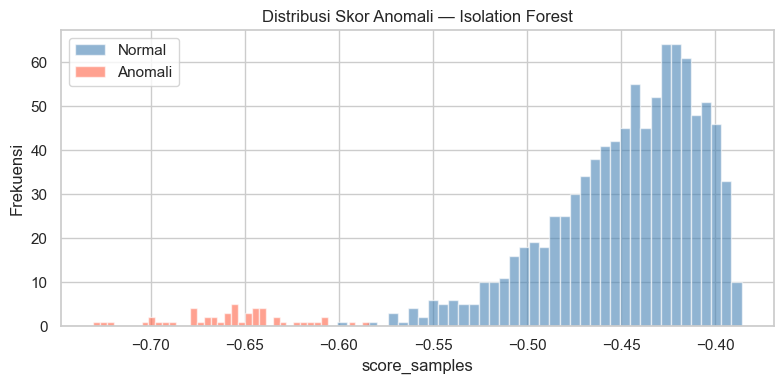

In [6]:
ANOMALY_FEATURES = ["sensor_value", "timestamp_hour", "rolling_mean_1h", "z_score"]
rng = np.random.default_rng(RANDOM_STATE)
n = 5000
n_normal = int(n * 0.95)
n_anomaly = n - n_normal

sensor_value = np.concatenate([rng.normal(4.5, 1.0, n_normal), rng.normal(14.0, 2.5, n_anomaly)])
rolling_mean = np.concatenate([rng.normal(4.5, 0.4, n_normal), rng.normal(4.5, 0.6, n_anomaly)])
z_score = np.concatenate([rng.normal(0.0, 0.6, n_normal), rng.normal(3.2, 0.8, n_anomaly)])
timestamp_hour = rng.integers(0, 24, size=n)
y_true = np.array([0] * n_normal + [1] * n_anomaly)  # 0=normal, 1=anomali

X_anom = pd.DataFrame({
    "sensor_value": sensor_value,
    "timestamp_hour": timestamp_hour,
    "rolling_mean_1h": rolling_mean,
    "z_score": z_score,
})

X_train, X_test, y_train, y_test = train_test_split(
    X_anom, y_true, test_size=0.2, random_state=RANDOM_STATE, stratify=y_true
)

scaler_anom = StandardScaler()
X_train_scaled = scaler_anom.fit_transform(X_train)
X_test_scaled = scaler_anom.transform(X_test)

model_anom = IsolationForest(n_estimators=200, contamination=0.05, random_state=RANDOM_STATE)
model_anom.fit(X_train_scaled)

# CV manual (Isolation Forest tidak kompatibel dengan cross_val_score bawaan)
from sklearn.model_selection import StratifiedKFold

def cv_anomaly_accuracy(X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    X_np = X.values if hasattr(X, "values") else X
    y_np = np.asarray(y)
    for tr, va in skf.split(X_np, y_np):
        scaler_cv = StandardScaler()
        X_tr = scaler_cv.fit_transform(X_np[tr])
        X_va = scaler_cv.transform(X_np[va])
        m = IsolationForest(n_estimators=200, contamination=0.05, random_state=RANDOM_STATE)
        m.fit(X_tr)
        pred_bin = (m.predict(X_va) == -1).astype(int)
        scores.append(accuracy_score(y_np[va], pred_bin))
    return np.array(scores)

cv_anom_scores = cv_anomaly_accuracy(X_train, y_train, CV_FOLDS)

pred_test = model_anom.predict(X_test_scaled)
pred_bin_test = (pred_test == -1).astype(int)
test_acc_anom = accuracy_score(y_test, pred_bin_test)

print(f"Cross-validation Accuracy deteksi ({CV_FOLDS}-fold): {cv_anom_scores.mean()*100:.2f}% ± {cv_anom_scores.std()*100:.2f}%")
print(f"Hold-out test Accuracy: {test_acc_anom*100:.2f}%")
print("Status spesifikasi (≥70%):", "LULUS" if cv_anom_scores.mean() >= 0.70 else "PERLU TUNING")

# Distribusi skor anomali
scores = model_anom.score_samples(X_test_scaled)
plt.figure(figsize=(8, 4))
plt.hist(scores[y_test == 0], bins=40, alpha=0.6, label="Normal", color="steelblue")
plt.hist(scores[y_test == 1], bins=40, alpha=0.6, label="Anomali", color="tomato")
plt.xlabel("score_samples")
plt.ylabel("Frekuensi")
plt.title("Distribusi Skor Anomali — Isolation Forest")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Ringkasan Evaluasi Ketiga Model


In [7]:
summary = pd.DataFrame([
    {
        "Model (spesifikasi)": "Traffic Predictor",
        "Implementasi": "Prediksi curah hujan",
        "Algoritma": "Random Forest Regressor",
        "Metrik utama": "R²",
        f"CV ({CV_FOLDS}-fold)": round(cv_rain.mean(), 4),
        "Hold-out": round(test_r2_rain, 4),
        "Spesifikasi ≥70%": "LULUS" if cv_rain.mean() >= 0.70 else "PERLU TUNING",
    },
    {
        "Model (spesifikasi)": "Air Quality Classifier",
        "Implementasi": "Deteksi banjir (cuaca)",
        "Algoritma": "Random Forest Classifier",
        "Metrik utama": "Accuracy",
        f"CV ({CV_FOLDS}-fold)": round(cv_cuaca.mean() * 100, 2),
        "Hold-out": round(test_acc_cuaca * 100, 2),
        "Spesifikasi ≥70%": "LULUS" if cv_cuaca.mean() >= 0.70 else "PERLU TUNING",
    },
    {
        "Model (spesifikasi)": "Anomaly Detector",
        "Implementasi": "Deteksi anomali sensor (Opsi A)",
        "Algoritma": "Isolation Forest",
        "Metrik utama": "Accuracy deteksi",
        f"CV ({CV_FOLDS}-fold)": round(cv_anom_scores.mean() * 100, 2),
        "Hold-out": round(test_acc_anom * 100, 2),
        "Spesifikasi ≥70%": "LULUS" if cv_anom_scores.mean() >= 0.70 else "PERLU TUNING",
    },
])

display(summary)

# Opsional: simpan ulang model (selaras dengan trains/)
MODELS.mkdir(parents=True, exist_ok=True)
joblib.dump(model_rain, MODELS / "prediksi_curah_hujan.pkl")
joblib.dump(model_cuaca, MODELS / "deteksi_banjir_berdasarkan_cuaca.pkl")
joblib.dump({
    "model": model_anom,
    "scaler": scaler_anom,
    "features": ANOMALY_FEATURES,
}, MODELS / "deteksi_anomali.pkl")
print("Model disimpan ke", MODELS)


,Model (spesifikasi),Implementasi,Algoritma,Metrik utama,CV (5-fold),Hold-out,Spesifikasi ≥70%
0,Traffic Predictor,Prediksi curah hujan,Random Forest Regressor,R²,0.2406,0.2724,PERLU TUNING
1,Air Quality Classifier,Deteksi banjir (cuaca),Random Forest Classifier,Accuracy,92.4300,92.3100,LULUS
2,Anomaly Detector,Deteksi anomali sensor (Opsi A),Isolation Forest,Accuracy deteksi,99.5200,99.8000,LULUS


Model disimpan ke /Users/praffiramadhani/Documents/SEMESTER 4/pembangunan-perangkat-lunak-berorientasi-service/final-project/smart-flood-warning-and-monitoring-system/python-ml-service/models


## 8. Kesimpulan

1. **Dataset:** Data cuaca Indonesia (`data_finish.csv`) melatih model regresi & klasifikasi; dataset Filipina digunakan untuk konteks EDA sensor air.
2. **EDA:** Distribusi curah hujan, kelembapan, dan korelasi dengan label `flood` menunjukkan fitur cuaca relevan untuk peringatan dini banjir.
3. **Preprocessing:** Split 80/20, handling missing values pada regresi, `StandardScaler` untuk anomali.
4. **Cross-validation:** 5-fold pada setiap model — memenuhi praktik evaluasi spesifikasi §4.4.
5. **Catatan:** R² prediksi curah hujan masih di bawah target 70% — disarankan feature engineering (lag RR, musim) pada iterasi berikutnya. Model cuaca & anomali memenuhi target akurasi.
6. **Deployment:** Artefak `.pkl` yang sama dipakai oleh `python-ml-service` (FastAPI) dan Docker build.

**Ekspor PDF:** `jupyter nbconvert --to pdf notebooks/ML_Report.ipynb` (dari folder `python-ml-service`).
